In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Bibliotecas carregadas com sucesso.")

Bibliotecas carregadas com sucesso.


In [2]:
from getpass import getpass

TOKEN = getpass("Digite seu AppToken: ")

In [3]:
URL = (
    "http://api.sefaz.al.gov.br/"
    "sfz-economiza-alagoas-api/api/public/"
    "produto/pesquisa"
)

headers = {
    "AppToken": TOKEN,
    "Content-Type": "application/json"
}

## Configuração de coleta

In [4]:
CODIGO_IBGE = 2704302 


materiais = [
    "CIMENTO",
    "AREIA",
    "BRITA",
    "TIJOLO",
    "TINTA"
]


GPC_CONSTRUCAO = "83000000"


DIAS_PESQUISA = 10

In [5]:
import socket

ip = socket.gethostbyname("api.sefaz.al.gov.br")

print("IP encontrado:", ip)

IP encontrado: 45.235.226.26


## Teste da API

In [6]:
payload = {
    "produto": {
        "descricao": "CIMENTO",
        "gpc": GPC_CONSTRUCAO
    },
    "estabelecimento": {
        "municipio": {
            "codigoIBGE": CODIGO_IBGE
        }
    },
    "dias": DIAS_PESQUISA,
    "pagina": 1,
    "registrosPorPagina": 5000
}

In [7]:
resposta = requests.post(
    URL,
    headers=headers,
    json=payload,
    timeout=60
)

print("Status:", resposta.status_code)

resultado = resposta.json()

print("Total de registros:", resultado.get("totalRegistros"))
print("Total de páginas:", resultado.get("totalPaginas"))

Status: 200
Total de registros: 262
Total de páginas: 1


## Coleta automatizada dos dados

In [8]:
def buscar_material(material, pagina=1):

    payload = {
        "produto": {
            "descricao": material,
            "gpc": GPC_CONSTRUCAO
        },
        "estabelecimento": {
            "municipio": {
                "codigoIBGE": CODIGO_IBGE
            }
        },
        "dias": DIAS_PESQUISA,
        "pagina": pagina,
        "registrosPorPagina": 5000
    }

    resposta = requests.post(
        URL,
        headers=headers,
        json=payload,
        timeout=60
    )

    resposta.raise_for_status()

    resultado = resposta.json()

    if "message" in resultado:
        raise Exception(resultado["message"])

    return resultado

In [9]:
teste = buscar_material("CIMENTO")

print("Total encontrado:", teste["totalRegistros"])
print("Total de páginas:", teste["totalPaginas"])
print("Registros nesta página:", teste["registrosPagina"])

Total encontrado: 262
Total de páginas: 1
Registros nesta página: 262


In [10]:
def buscar_todos_registros(material):

    registros = []
    pagina = 1

    while True:

        resultado = buscar_material(
            material,
            pagina
        )

        conteudo = resultado.get("conteudo", [])

        registros.extend(conteudo)

        print(
            f"{material} | "
            f"Página {pagina} | "
            f"{len(conteudo)} registros"
        )

        if resultado.get("ultimaPagina", True):
            break

        pagina += 1

    return registros

In [11]:
todos_registros = []

for material in materiais:

    registros = buscar_todos_registros(material)

    for registro in registros:
        registro["material_busca"] = material

    todos_registros.extend(registros)

print()
print("Total geral coletado:", len(todos_registros))

CIMENTO | Página 1 | 262 registros
AREIA | Página 1 | 592 registros
BRITA | Página 1 | 37 registros
TIJOLO | Página 1 | 31 registros
TINTA | Página 1 | 3079 registros

Total geral coletado: 4001


## Organização da base de dados

In [12]:
df_raw = pd.json_normalize(todos_registros)

df_raw.head()

,material_busca,produto.codigo,produto.descricao,produto.gtin,produto.ncm,produto.gpc,produto.unidadeMedida,produto.venda.dataVenda,produto.venda.valorDeclarado,produto.venda.valorVenda,...,estabelecimento.endereco.nomeLogradouro,estabelecimento.endereco.numeroImovel,estabelecimento.endereco.bairro,estabelecimento.endereco.cep,estabelecimento.endereco.codigoIBGE,estabelecimento.endereco.municipio,estabelecimento.endereco.latitude,estabelecimento.endereco.longitude,estabelecimento.telefone,produto.descricaoSefaz
0,CIMENTO,014498,CIMENTO KG POTY,0,25232910,83000000,UN,2026-09-16T14:17:02Z,1.5,1.5,...,AV DR JULIO MARQUES LUZ,1254,JATIUCA,57035420,2704302,MACEIO,-9.653243,-35.710408,NaN,NaN
1,CIMENTO,0000000001151,CIMENTO 1KG,0,25232910,83000000,KG,2026-09-16T14:52:57Z,1.5,1.5,...,Rua DR. JOAO CRISOSTOMO DE FARIAS,178,CLIMA BOM,57071090,2704302,MACEIO,-9.571827,-35.777935,NaN,NaN
2,CIMENTO,3446,CIMENTO KG,0,38245000,83000000,SC,2026-09-16T14:11:02Z,1.5,1.5,...,3A TV da Saudade,155,Jacintinho,57042116,2704302,MACEIO,0.000000,0.000000,(82) 30252019,NaN
3,CIMENTO,010067,CIMENTO BRANCO RHOTA,0,38245000,83000000,KG,2026-09-16T12:20:28Z,6.6,1.5,...,AV DR JULIO MARQUES LUZ,1254,JATIUCA,57035420,2704302,MACEIO,-9.653243,-35.710408,NaN,NaN
4,CIMENTO,000862,CIMENTO ZUMBI 1 KG,0,25221000,83000000,KG,2026-09-12T14:22:55Z,2.0,2.0,...,Rua Paulo Holanda Costa,510,Cidade Universitária,57073678,2704302,MACEIO,0.000000,0.000000,(82) 993651382,NaN


In [13]:
df_raw.columns.tolist()

['material_busca',
 'produto.codigo',
 'produto.descricao',
 'produto.gtin',
 'produto.ncm',
 'produto.gpc',
 'produto.unidadeMedida',
 'produto.venda.dataVenda',
 'produto.venda.valorDeclarado',
 'produto.venda.valorVenda',
 'estabelecimento.cnpj',
 'estabelecimento.razaoSocial',
 'estabelecimento.nomeFantasia',
 'estabelecimento.endereco.nomeLogradouro',
 'estabelecimento.endereco.numeroImovel',
 'estabelecimento.endereco.bairro',
 'estabelecimento.endereco.cep',
 'estabelecimento.endereco.codigoIBGE',
 'estabelecimento.endereco.municipio',
 'estabelecimento.endereco.latitude',
 'estabelecimento.endereco.longitude',
 'estabelecimento.telefone',
 'produto.descricaoSefaz']

In [14]:
colunas = {
    "material_busca": "material",
    "produto.codigo": "codigo_produto",
    "produto.descricao": "descricao",
    "produto.descricaoSefaz": "descricao_sefaz",
    "produto.gtin": "gtin",
    "produto.ncm": "ncm",
    "produto.gpc": "gpc",
    "produto.unidadeMedida": "unidade",
    "produto.venda.dataVenda": "data_venda",
    "produto.venda.valorDeclarado": "valor_declarado",
    "produto.venda.valorVenda": "preco",
    "estabelecimento.cnpj": "cnpj",
    "estabelecimento.razaoSocial": "razao_social",
    "estabelecimento.nomeFantasia": "estabelecimento",
    "estabelecimento.endereco.bairro": "bairro",
    "estabelecimento.endereco.municipio": "municipio"
}

colunas_existentes = {
    origem: destino
    for origem, destino in colunas.items()
    if origem in df_raw.columns
}

df = df_raw[
    list(colunas_existentes.keys())
].rename(
    columns=colunas_existentes
)

df.head()

,material,codigo_produto,descricao,descricao_sefaz,gtin,ncm,gpc,unidade,data_venda,valor_declarado,preco,cnpj,razao_social,estabelecimento,bairro,municipio
0,CIMENTO,014498,CIMENTO KG POTY,NaN,0,25232910,83000000,UN,2026-09-16T14:17:02Z,1.5,1.5,35722180000108,G SILVA MATERIAL DE CONSTRUCOES LTDA,G SILVA MATERIAL DE CONSTRUÇÃO E FERRAGEM,JATIUCA,MACEIO
1,CIMENTO,0000000001151,CIMENTO 1KG,NaN,0,25232910,83000000,KG,2026-09-16T14:52:57Z,1.5,1.5,00837552000159,JOSE CARLOS DOS SANTOS CONSTRUCAO LTDA,GG CASA & CONSTRUCAO,CLIMA BOM,MACEIO
2,CIMENTO,3446,CIMENTO KG,NaN,0,38245000,83000000,SC,2026-09-16T14:11:02Z,1.5,1.5,49850828000128,CONSTRUCAR MATERIAL DE CONSTRUCAO LTDA,NaN,Jacintinho,MACEIO
3,CIMENTO,010067,CIMENTO BRANCO RHOTA,NaN,0,38245000,83000000,KG,2026-09-16T12:20:28Z,6.6,1.5,35722180000108,G SILVA MATERIAL DE CONSTRUCOES LTDA,G SILVA MATERIAL DE CONSTRUÇÃO E FERRAGEM,JATIUCA,MACEIO
4,CIMENTO,000862,CIMENTO ZUMBI 1 KG,NaN,0,25221000,83000000,KG,2026-09-12T14:22:55Z,2.0,2.0,55206191000134,MIX MATERIAL DE CONSTRUCOES LTDA,NaN,Cidade Universitária,MACEIO


In [15]:
df.to_csv(
    "dados_economiza_alagoas_brutos.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Arquivo salvo.")

Arquivo salvo.


## Conhecendo a base de dados

In [16]:
display(df.head())

print("Linhas e colunas:", df.shape)

df.info()

,material,codigo_produto,descricao,descricao_sefaz,gtin,ncm,gpc,unidade,data_venda,valor_declarado,preco,cnpj,razao_social,estabelecimento,bairro,municipio
0,CIMENTO,014498,CIMENTO KG POTY,NaN,0,25232910,83000000,UN,2026-09-16T14:17:02Z,1.5,1.5,35722180000108,G SILVA MATERIAL DE CONSTRUCOES LTDA,G SILVA MATERIAL DE CONSTRUÇÃO E FERRAGEM,JATIUCA,MACEIO
1,CIMENTO,0000000001151,CIMENTO 1KG,NaN,0,25232910,83000000,KG,2026-09-16T14:52:57Z,1.5,1.5,00837552000159,JOSE CARLOS DOS SANTOS CONSTRUCAO LTDA,GG CASA & CONSTRUCAO,CLIMA BOM,MACEIO
2,CIMENTO,3446,CIMENTO KG,NaN,0,38245000,83000000,SC,2026-09-16T14:11:02Z,1.5,1.5,49850828000128,CONSTRUCAR MATERIAL DE CONSTRUCAO LTDA,NaN,Jacintinho,MACEIO
3,CIMENTO,010067,CIMENTO BRANCO RHOTA,NaN,0,38245000,83000000,KG,2026-09-16T12:20:28Z,6.6,1.5,35722180000108,G SILVA MATERIAL DE CONSTRUCOES LTDA,G SILVA MATERIAL DE CONSTRUÇÃO E FERRAGEM,JATIUCA,MACEIO
4,CIMENTO,000862,CIMENTO ZUMBI 1 KG,NaN,0,25221000,83000000,KG,2026-09-12T14:22:55Z,2.0,2.0,55206191000134,MIX MATERIAL DE CONSTRUCOES LTDA,NaN,Cidade Universitária,MACEIO


Linhas e colunas: (4001, 16)
<class 'pandas.DataFrame'>
RangeIndex: 4001 entries, 0 to 4000
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   material         4001 non-null   str    
 1   codigo_produto   4001 non-null   str    
 2   descricao        4001 non-null   str    
 3   descricao_sefaz  1468 non-null   str    
 4   gtin             4001 non-null   str    
 5   ncm              4001 non-null   str    
 6   gpc              4001 non-null   str    
 7   unidade          4001 non-null   str    
 8   data_venda       4001 non-null   str    
 9   valor_declarado  4001 non-null   float64
 10  preco            4001 non-null   float64
 11  cnpj             4001 non-null   str    
 12  razao_social     4001 non-null   str    
 13  estabelecimento  3105 non-null   str    
 14  bairro           4001 non-null   str    
 15  municipio        4001 non-null   str    
dtypes: float64(2), str(14)
memory usage: 500.3

In [17]:
display(df.describe(include="all"))

print("\nValores ausentes:")
print(df.isnull().sum())

,material,codigo_produto,descricao,descricao_sefaz,gtin,ncm,gpc,unidade,data_venda,valor_declarado,preco,cnpj,razao_social,estabelecimento,bairro,municipio
count,4001,4001,4001,1468,4001,4001,4001,4001,4001,4001.000000,4001.000000,4001,4001,3105,4001,4001
unique,5,3082,3013,626,1240,47,1,69,3496,NaN,NaN,441,383,301,79,1
top,TINTA,CFOP5405,TINTA P TECIDO 37ML,TINTA AEROSSOL PRETO FOSCO USO GERAL 350 ML/25...,0,32091010,83000000,UN,2026-09-09T16:26:48Z,NaN,NaN,03656804000131,CARAJAS MATERIAL DE CONSTRUCAO LTDA,CARAJAS CONSTRUCAO,CENTRO,MACEIO
freq,3079,10,26,20,1515,1885,4001,2069,11,NaN,NaN,320,567,567,362,4001
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,101.846423,98.681765,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,135.366731,131.105212,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.350000,0.350000,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.990000,20.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48.600000,46.075000,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,120.000000,119.000000,NaN,NaN,NaN,NaN,NaN



Valores ausentes:
material              0
codigo_produto        0
descricao             0
descricao_sefaz    2533
gtin                  0
ncm                   0
gpc                   0
unidade               0
data_venda            0
valor_declarado       0
preco                 0
cnpj                  0
razao_social          0
estabelecimento     896
bairro                0
municipio             0
dtype: int64


### Tratamento dos valores ausentes

Foram identificados valores ausentes nos campos `descricao_sefaz`
e `estabelecimento`.

Como essas informações possuem campos equivalentes na própria base,
optou-se por preservar os registros.

Quando `descricao_sefaz` estava ausente, foi utilizada a variável
`descricao`.

Quando o nome fantasia do estabelecimento estava ausente, foi
utilizada a `razao_social`.

Dessa forma, evitou-se a exclusão desnecessária de registros válidos,
sem realizar imputações artificiais sobre preços ou demais variáveis
numéricas.

In [18]:
df["descricao_sefaz"] = df["descricao_sefaz"].fillna(
    df["descricao"]
)

df["estabelecimento"] = df["estabelecimento"].fillna(
    df["razao_social"]
)

In [19]:
print("Valores ausentes após o tratamento:")

print(
    df.isnull().sum()
)

Valores ausentes após o tratamento:
material           0
codigo_produto     0
descricao          0
descricao_sefaz    0
gtin               0
ncm                0
gpc                0
unidade            0
data_venda         0
valor_declarado    0
preco              0
cnpj               0
razao_social       0
estabelecimento    0
bairro             0
municipio          0
dtype: int64


## Tratamento Preço e data

In [20]:
df["preco"] = pd.to_numeric(
    df["preco"],
    errors="coerce"
)

df["valor_declarado"] = pd.to_numeric(
    df["valor_declarado"],
    errors="coerce"
)

In [21]:
df["data_venda"] = pd.to_datetime(
    df["data_venda"],
    errors="coerce",
    utc=True
)

df["data_venda"] = (
    df["data_venda"]
    .dt.tz_convert("America/Maceio")
)

df[["data_venda"]].head()

,data_venda
0,2026-09-16 11:17:02-03:00
1,2026-09-16 11:52:57-03:00
2,2026-09-16 11:11:02-03:00
3,2026-09-16 09:20:28-03:00
4,2026-09-12 11:22:55-03:00


In [22]:
print("Valores ausentes após conversões:")

print(
    df[
        [
            "preco",
            "valor_declarado",
            "data_venda"
        ]
    ].isnull().sum()
)

Valores ausentes após conversões:
preco              0
valor_declarado    0
data_venda         0
dtype: int64


In [23]:
#Remoção de registros sem preços (outliers não são removidos neste momento)

antes = len(df)

df = df.dropna(
    subset=["preco"]
).copy()

depois = len(df)

print("Antes:", antes)
print("Depois:", depois)
print("Registros removidos:", antes - depois)

Antes: 4001
Depois: 4001
Registros removidos: 0


In [24]:
print(
    "Registros completamente duplicados:",
    df.duplicated().sum()
)

Registros completamente duplicados: 0


## Análise da qualidade dos dados

In [25]:
tabela_unidades = pd.crosstab(
    df["material"],
    df["unidade"]
)

display(tabela_unidades)

unidade,1/,1/4,400ML,BA,BALDE,BB,BD,BL,BP,CX,...,UNI,UNID,UNIDA,Un,Unid,fd,m,m2,sc,un
material,,,,,,,,,,,,,,,,,,,,,
AREIA,0,0,0,0,0,0,13,1,0,3,...,8,14,0,7,1,1,1,0,1,1
BRITA,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
CIMENTO,0,0,0,1,0,0,0,0,0,1,...,0,6,0,0,0,0,0,0,0,1
TIJOLO,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
TINTA,1,4,3,1,2,1,133,15,1,3,...,0,12,3,3,0,0,0,0,0,6


In [26]:
for material in materiais:

    print("\n" + "=" * 70)
    print(material)
    print("=" * 70)

    dados_material = df[
        df["material"] == material
    ]

    display(
        dados_material[
            [
                "descricao",
                "descricao_sefaz",
                "unidade",
                "preco"
            ]
        ].head(30)
    )


CIMENTO


,descricao,descricao_sefaz,unidade,preco
0,CIMENTO KG POTY,CIMENTO KG POTY,UN,1.50
1,CIMENTO 1KG,CIMENTO 1KG,KG,1.50
2,CIMENTO KG,CIMENTO KG,SC,1.50
3,CIMENTO BRANCO RHOTA,CIMENTO BRANCO RHOTA,KG,1.50
4,CIMENTO ZUMBI 1 KG,CIMENTO ZUMBI 1 KG,KG,2.00
5,CIMENTO 1KG USO GERAL CPII F-32 ZEBU,CIMENTO CP II-F-32 ZEBU USO GERAL SACO 50KG,UN,2.00
6,CIMENTO 1KG,CIMENTO 1KG,KG,2.00
7,CIMENTO KG,CIMENTO KG,Kg,2.00
8,CIMENTO - SACO DE 1 KG,CIMENTO - SACO DE 1 KG,UN,2.00
9,CIMENTO CP II-Z-32 ZEBU USO GERAL KG,CIMENTO CP II-F-32 ZEBU USO GERAL SACO 50KG,KG,2.34



AREIA


,descricao,descricao_sefaz,unidade,preco
262,LIXA DE AREIA REDONDA 115MM X40 C10 UN,LIXA DE AREIA REDONDA 115MM X40 C10 UN,UN,1.000
263,LIXA DE AREIA REDONDA 115MM X 60,LIXA DE AREIA REDONDA 115MM X 60,UN,1.000
264,"FITA MATT SOFT AREIA NORONHA 0,45mm x H22 20mts","FITA MATT SOFT AREIA NORONHA 0,45mm x H22 20mts",ML,2.349
265,AREIA 450G - TERRA BRASIL,AREIA DECORATIVA COLORS 400GR,PC,2.600
266,"FITA MATT SOFT AREIA NORONHA 0,45mm x H22 20mts","FITA MATT SOFT AREIA NORONHA 0,45mm x H22 20mts",ML,2.600
267,AREIA 450G,AREIA DECORATIVA COLORS 400GR,UN,2.890
268,AREIA 450G - 1X450G,AREIA DECORATIVA COLORS 400GR,UN,2.890
269,AREIA 450G - 1X450G,AREIA DECORATIVA COLORS 400GR,UN,2.890
270,AREIA 450G - 1X450G,AREIA DECORATIVA COLORS 400GR,UN,2.890
271,CANTONINHO - AREIA PARA PASSAROS - FD 6GR X 450G,CANTONINHO - AREIA PARA PASSAROS - FD 6GR X 450G,UN,4.000



BRITA


,descricao,descricao_sefaz,unidade,preco
854,BRITA 0 RHOTA 25KG,BRITA 0 RHOTA 25KG,UN,5.970000
855,BRITA 20Kg,BRITA 20Kg,UN,9.000000
856,BRITA,BRITA,UN,10.000000
857,LATA DE BRITA 3/4 M3,LATA DE BRITA 3/4 M3,UN,10.000000
858,SACOS DE AREIA E BRITA,SACOS DE AREIA E BRITA,SC,10.000000
859,PACOTE DE BRITA 25 KG,PACOTE DE BRITA 25 KG,UN,12.000000
860,BRITA 25KG,BRITA 25KG,UN,13.000000
861,BRITA LATA,BRITA LATA,UN,13.000000
862,BRITA ZERO 25KG FIXAPLUS 1,BRITA ZERO 25KG FIXAPLUS 1,SC,13.205000
863,BRITA 0 (ENSACADA),BRITA 0 (ENSACADA),UN,13.500000



TIJOLO


,descricao,descricao_sefaz,unidade,preco
891,BUCHA U-FU 6MM USAF,BUCHA P/ FIXACAO TIJOLO FURAD 06 UFU C/2,UN,0.350
892,BUCHA U-FU 10MM USAF,BUCHA P/ FIXACAO TIJOLO FURAD 10 UFU C/50 USAF...,UN,0.700
893,TIJOLO 8 FUROS ( ACIMA DE 100 UNIDADES ),TIJOLO 8 FUROS ( ACIMA DE 100 UNIDADES ),UN,0.960
894,TIJOLOS 8 FUROS,TIJOLOS 8 FUROS,UN,1.000
895,TIJOLO 8 FUROS,TIJOLO 8 FUROS,UN,1.000
896,TIJOLOS,TIJOLOS,UN,1.000
897,TIJOLO 8 FUROS 19X19,TIJOLO 8 FUROS 19X19,UN,1.098
898,TIJOLO 8 FUROS,TIJOLO 8 FUROS,UN,1.100
899,TIJOLO 8F 9X19X19 - 2 IRMAOS,TIJOLO 8F 9X19X19 - 2 IRMAOS,UN,1.100
900,TIJOLO 8 FUROS,TIJOLO 8 FUROS,UN,1.100



TINTA


,descricao,descricao_sefaz,unidade,preco
922,COADOR DESCARTAVEL P TINTA,COADOR DESCARTAVEL P TINTA,LT,1.000000
923,TINTA ACRILICA BRILH,TINTA ACRILICA BRILH,UN,2.000000
924,TINTA ACRILICA FOSCA,TINTA ACRILICA FOSCA,UN,2.000000
925,TINTA LIQUIDA ARTISTICA VERMELHA 15ML - ROSTIN...,TINTA LIQUIDA ARTISTICA VERMELHA 15ML - ROSTIN...,UN,2.050000
926,TINTA ESM.SINT.100ML TINTAS LUX,TINTA ESM.SINT.100ML TINTAS LUX,UN,2.200000
927,TINTA LIQUIDA ARTISTICA PELE 1 15ML - ROSTINHO...,TINTA LIQUIDA ARTISTICA PELE 1 15ML - ROSTINHO...,UN,2.470000
928,TINTA LIQUIDA ARTISTICA PINK FLUOR 15ML - ROST...,TINTA LIQUIDA ARTISTICA PINK FLUOR 15ML - ROST...,UN,2.470000
929,PROMOCAO TINTA FOSCA,PROMOCAO TINTA FOSCA,UN,2.750000
930,POLIDOR LIMPA BOM 500ML,POLIDOR DE ALUMINIO LIMPA BOM R MAIS500M - 1X5...,UN,2.790000
931,CORANTE VIOLETA 50ML HIDROTINTAS,BISNAGA CORANTE VIOLETA 50ML HIDRO COLOR HIDRO...,UND,3.150000


In [27]:
quantidade_material = (
    df["material"]
    .value_counts()
    .rename_axis("material")
    .reset_index(name="quantidade")
)

display(quantidade_material)

,material,quantidade
0,TINTA,3079
1,AREIA,592
2,CIMENTO,262
3,BRITA,37
4,TIJOLO,31


In [28]:
df_original = df.copy()
df_analise = df.copy()

print("Registros na base original:", len(df_original))
print("Registros na base de análise:", len(df_analise))

Registros na base original: 4001
Registros na base de análise: 4001


In [29]:
#Outliers

def identificar_outliers(grupo):

    q1 = grupo["preco"].quantile(0.25)
    q3 = grupo["preco"].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    return grupo[
        (grupo["preco"] < limite_inferior) |
        (grupo["preco"] > limite_superior)
    ]

In [30]:
cimento_ncm = (
    df_analise[
        df_analise["material"] == "CIMENTO"
    ]
    .groupby("ncm")
    .agg(
        quantidade=("descricao", "count"),
        preco_minimo=("preco", "min"),
        preco_maximo=("preco", "max")
    )
    .sort_values(
        "quantidade",
        ascending=False
    )
)

display(cimento_ncm)

,quantidade,preco_minimo,preco_maximo
ncm,,,
25232910,150,1.500000,70.000000
38245000,33,1.500000,82.900000
32091010,16,84.900000,340.560000
68109900,14,17.000000,62.050000
32141020,10,103.000000,804.900000
25232100,8,4.890000,20.900000
32149000,6,9.900000,48.000000
25221000,5,2.000000,46.000000
69072200,4,29.889328,34.878049


### Refinamento da categoria CIMENTO pelo NCM

A inspeção dos possíveis outliers demonstrou que a busca textual por
"CIMENTO" também retornou produtos de acabamento, objetos, tintas,
texturas, cal e outros materiais que apenas possuíam o termo na descrição.

Para reduzir esse problema, foi analisado o NCM dos produtos. O código
25232910 corresponde a cimentos Portland comuns e foi adotado como
referência para a análise do cimento convencional.

Entretanto, mesmo dentro desse NCM, ainda podem existir diferentes
formas de comercialização e apresentações, sendo necessária uma
verificação adicional das descrições e unidades.

In [31]:
cimento_portland = df_analise[
    (df_analise["material"] == "CIMENTO") &
    (df_analise["ncm"].astype(str) == "25232910")
].copy()

print(
    "Registros de cimento Portland comum:",
    len(cimento_portland)
)

Registros de cimento Portland comum: 150


In [32]:
display(
    cimento_portland["unidade"]
    .value_counts()
    .rename_axis("unidade")
    .reset_index(name="quantidade")
)

,unidade,quantidade
0,UN,68
1,SC,29
2,KG,12
3,UND,7
4,PC,6
5,SAC,6
6,SACO,5
7,S25,5
8,UNID,4
9,S50,3


In [33]:
display(
    cimento_portland[
        [
            "descricao",
            "unidade",
            "preco",
            "estabelecimento"
        ]
    ]
    .sort_values("preco")
)

,descricao,unidade,preco,estabelecimento
0,CIMENTO KG POTY,UN,1.500,G SILVA MATERIAL DE CONSTRUÇÃO E FERRAGEM
1,CIMENTO 1KG,KG,1.500,GG CASA & CONSTRUCAO
5,CIMENTO 1KG USO GERAL CPII F-32 ZEBU,UN,2.000,PROKASA
6,CIMENTO 1KG,KG,2.000,GALPAO DA CONSTRUCAO
7,CIMENTO KG,Kg,2.000,CAMILA S DA L NASCIMENTO
...,...,...,...,...
223,CIMENTO ZEBU USO GERAL CPII F-32 50KG,SAC,50.000,COMERCIAL ARTHUR
224,CIMENTO ZUMBI CP II Z 32 50 KG,SC,52.000,DONA NENE CONSTRUCOES
225,CIMENTO POTY,UN,52.158,NOME DE FANTASIA - NULA
226,CIMENTO ZUMBI 50 KG,UNID,60.000,DEPOSITO ALVORADA


In [34]:
filtro_50kg = (
    cimento_portland["descricao"]
    .str.upper()
    .str.contains(r"\b50\s*KG\b", regex=True, na=False)
)

cimento_50kg = cimento_portland[
    filtro_50kg
].copy()

print(
    "Registros identificados explicitamente como 50 kg:",
    len(cimento_50kg)
)

Registros identificados explicitamente como 50 kg: 79


In [35]:
display(
    cimento_50kg[
        [
            "descricao",
            "unidade",
            "preco",
            "estabelecimento"
        ]
    ].sort_values("preco")
)

,descricao,unidade,preco,estabelecimento
81,CIMENTO CP IV 32 RS 50 KG,SC,23.00,M R CONSTRUCOES
84,CIMENTO 50KG ZEBU,UN,24.90,G SILVA MATERIAL DE CONSTRUÇÃO E FERRAGEM
98,CIMENTO ZEBU USO GERAL CPII F32 50KG D...,UN,26.90,LEROY MERLIN COMPANHIA BRASILEIRA DE BRICOLAGEM
118,CIMENTO NACIONAL CP-II-F-32 50 KG,SACO,31.40,GLOBAL CIMENTOS ALAGOAS LTDA
124,CIMENTO INTERCEMENT 50KG,UN,35.39,JH COMERCIAL
...,...,...,...,...
222,CIMENTO ZEBU USO GERAL CPII F-32 50KG,UN,50.00,IMPERDEKA
223,CIMENTO ZEBU USO GERAL CPII F-32 50KG,SAC,50.00,COMERCIAL ARTHUR
224,CIMENTO ZUMBI CP II Z 32 50 KG,SC,52.00,DONA NENE CONSTRUCOES
226,CIMENTO ZUMBI 50 KG,UNID,60.00,DEPOSITO ALVORADA


### Padronização da apresentação do cimento

A inspeção dos dados demonstrou que os registros classificados como
CIMENTO apresentavam diferentes tipos de produtos e apresentações.

Para tornar os preços comparáveis, a análise do cimento foi restringida
a produtos classificados no NCM 25232910 e cuja descrição identifica
explicitamente uma apresentação de 50 kg.

Foram encontrados 79 registros com essas características. Os demais
registros de cimento foram preservados separadamente, mas não foram
utilizados na comparação estatística de preços do material.

In [36]:
cimento_excluido_apresentacao = df_analise[
    (df_analise["material"] == "CIMENTO") &
    ~(
        (df_analise["ncm"].astype(str) == "25232910") &
        (
            df_analise["descricao"]
            .str.upper()
            .str.contains(r"\b50\s*KG\b", regex=True, na=False)
        )
    )
].copy()

print(
    "Registros de CIMENTO fora da padronização:",
    len(cimento_excluido_apresentacao)
)

Registros de CIMENTO fora da padronização: 183


In [37]:
df_analise = pd.concat(
    [
        df_analise[
            df_analise["material"] != "CIMENTO"
        ],
        cimento_50kg
    ],
    ignore_index=True
)

print(
    "Registros de CIMENTO após padronização:",
    (df_analise["material"] == "CIMENTO").sum()
)

print(
    "Total de registros na base de análise:",
    len(df_analise)
)

Registros de CIMENTO após padronização: 79
Total de registros na base de análise: 3818


### Avaliação da categoria AREIA

A busca textual por "AREIA" retornou produtos que não correspondem
necessariamente à areia utilizada na construção civil. Por isso,
os registros foram inspecionados considerando descrição, NCM,
unidade e preço antes da análise estatística.

In [38]:
areia = df_analise[
    df_analise["material"] == "AREIA"
].copy()

print("Quantidade de registros de AREIA:", len(areia))

print("\nNCMs mais frequentes:")
display(
    areia["ncm"]
    .value_counts()
    .rename_axis("ncm")
    .reset_index(name="quantidade")
    .head(15)
)

print("\nUnidades mais frequentes:")
display(
    areia["unidade"]
    .value_counts()
    .rename_axis("unidade")
    .reset_index(name="quantidade")
    .head(20)
)

print("\nMenores preços:")
display(
    areia[
        [
            "descricao",
            "descricao_sefaz",
            "ncm",
            "unidade",
            "preco"
        ]
    ]
    .sort_values("preco")
    .head(40)
)

print("\nMaiores preços:")
display(
    areia[
        [
            "descricao",
            "descricao_sefaz",
            "ncm",
            "unidade",
            "preco"
        ]
    ]
    .sort_values(
        "preco",
        ascending=False
    )
    .head(40)
)

Quantidade de registros de AREIA: 592

NCMs mais frequentes:


,ncm,quantidade
0,25081000,236
1,25059000,174
2,32091010,89
3,25051000,45
4,25084090,11
5,32081010,8
6,38245000,4
7,25232910,4
8,32089010,3
9,68053090,2



Unidades mais frequentes:


,unidade,quantidade
0,UN,322
1,UN0001,38
2,GL,31
3,UND,27
4,SC,21
5,UNID,14
6,UN0005,13
7,FD,13
8,BD,13
9,MT,10



Menores preços:


,descricao,descricao_sefaz,ncm,unidade,preco
0,LIXA DE AREIA REDONDA 115MM X40 C10 UN,LIXA DE AREIA REDONDA 115MM X40 C10 UN,68053090,UN,1.000
1,LIXA DE AREIA REDONDA 115MM X 60,LIXA DE AREIA REDONDA 115MM X 60,68053090,UN,1.000
2,"FITA MATT SOFT AREIA NORONHA 0,45mm x H22 20mts","FITA MATT SOFT AREIA NORONHA 0,45mm x H22 20mts",39162000,ML,2.349
3,AREIA 450G - TERRA BRASIL,AREIA DECORATIVA COLORS 400GR,25051000,PC,2.600
4,"FITA MATT SOFT AREIA NORONHA 0,45mm x H22 20mts","FITA MATT SOFT AREIA NORONHA 0,45mm x H22 20mts",39162000,ML,2.600
5,AREIA 450G,AREIA DECORATIVA COLORS 400GR,25051000,UN,2.890
6,AREIA 450G - 1X450G,AREIA DECORATIVA COLORS 400GR,25051000,UN,2.890
7,AREIA 450G - 1X450G,AREIA DECORATIVA COLORS 400GR,25051000,UN,2.890
8,AREIA 450G - 1X450G,AREIA DECORATIVA COLORS 400GR,25051000,UN,2.890
9,CANTONINHO - AREIA PARA PASSAROS - FD 6GR X 450G,CANTONINHO - AREIA PARA PASSAROS - FD 6GR X 450G,25059000,UN,4.000



Maiores preços:


,descricao,descricao_sefaz,ncm,unidade,preco
591,AREIA SUVINIL RM003 FACHADA PROTEGIDA EMBORRAC...,AREIA SUVINIL RM003 FACHADA PROTEGIDA EMBORRAC...,32091010,LA,890.670000
590,Tinta Acril Stan Rend Mto Areia 16L D...,Tinta Acril Stan Rend Mto Areia 16L D...,32091010,UN,451.720000
589,TINTA ACRILICA RENDE MUITO AREIA 16L CORAL,TINTA ACRILICA RENDE MUITO AREIA 16L CORAL,32091010,UN,439.900000
588,TINTA ACR FC 16L REND MUIT AREIA CORAL,TINTA ACR FC 16L REND MUIT AREIA CORAL LT0001LT,32091010,LT,435.990000
587,TINTA ACR.SEMI BRILHO 15LT AREIA IBRATIN - 951...,TINTA ACR.SEMI BRILHO 15LT AREIA IBRATIN - 951...,32091010,UN,399.990000
586,TINTA ACR STANDARD RENDE E COBRE MUITO AREIA F...,SUVINIL ACR STD FOSCO RENDE E COBRE MUITO AREI...,32091010,LA,380.470000
585,TINTA ACR STANDARD MAXIMA EFICIENCIA AREIA FOS...,GLASURIT ACR FOSCO MAXIMA EFICIENCIA AREIA 18L,32091010,LA,356.400000
584,TEXT GRANFFINO PEDRAS NATURAIS AREIA INT/EXT B...,TEXT GRANFFINO PEDRAS NATURAIS AREIA INT/EXT B...,32091010,LA,345.900000
583,ACR FOSCO AREIA 18L MIRACRIL MIRACOR,ACR FOSCO AREIA 18L MIRACRIL MIRACOR,32091010,BD,311.420000
581,Ped Nat Areia 20Kg Hydronorth,Ped Nat Areia 20Kg Hydronorth,32091010,UN,308.400000


In [39]:
areia_construcao = areia[
    (
        areia["ncm"]
        .astype(str)
        .isin(["25059000", "25051000"])
    )
    &
    (
        areia["unidade"]
        .astype(str)
        .str.upper()
        .eq("MT")
    )
    &
    (
        ~areia["descricao"]
        .str.upper()
        .str.contains("MEIO METRO", na=False)
    )
].copy()

print(
    "Registros de AREIA após padronização:",
    len(areia_construcao)
)

display(
    areia_construcao[
        [
            "descricao",
            "ncm",
            "unidade",
            "preco",
            "estabelecimento"
        ]
    ].sort_values("preco")
)

Registros de AREIA após padronização: 9


,descricao,ncm,unidade,preco,estabelecimento
536,AREIA,25059000,MT,140.0,ERONILDE TENORIO DE ARAUJO - ME
545,AREIA GROSSA,25051000,MT,150.0,RIO NEGRO CONSTRUCOES
546,AREIA FINA,25051000,MT,150.0,RIO NEGRO CONSTRUCOES
551,AREIA LAVADA GROSSA,25051000,MT,160.0,HORIZONTE MATERIAIS DE CONSTRUCAO
565,AREIA M3 - GROSSA,25051000,MT,200.0,SS COMERCIAL
566,AREIA M3 - FINA,25051000,MT,200.0,SS COMERCIAL
567,AREIA M3 - MEDIA,25051000,MT,200.0,SS COMERCIAL
568,AREIA MEDIA SEM MARCA,25059000,MT,200.0,PACOM PATRIOTA COMERCIAL LTDA - EPP
575,AREIA (METRO ),25051000,MT,250.0,DONA NENE CONSTRUCOES


In [40]:
df_analise = pd.concat(
    [
        df_analise[
            df_analise["material"] != "AREIA"
        ],
        areia_construcao
    ],
    ignore_index=True
)

print(
    "Registros de AREIA após padronização:",
    (df_analise["material"] == "AREIA").sum()
)

print(
    "Total de registros na base de análise:",
    len(df_analise)
)

Registros de AREIA após padronização: 9
Total de registros na base de análise: 3235


### Avaliação das categorias BRITA e TIJOLO

Como BRITA e TIJOLO possuem uma quantidade menor de registros,
foi realizada uma inspeção direta das descrições, NCMs, unidades
e preços para verificar a presença de produtos inadequados ou
apresentações não comparáveis.

In [41]:
for material in ["BRITA", "TIJOLO"]:

    grupo = df_analise[
        df_analise["material"] == material
    ].copy()

    print("\n" + "=" * 70)
    print(material)
    print("=" * 70)

    print(
        f"\nQuantidade de registros: {len(grupo)}"
    )

    print("\nNCMs:")
    display(
        grupo["ncm"]
        .value_counts()
        .rename_axis("ncm")
        .reset_index(name="quantidade")
    )

    print("\nUnidades:")
    display(
        grupo["unidade"]
        .value_counts()
        .rename_axis("unidade")
        .reset_index(name="quantidade")
    )

    print("\nTodos os registros:")

    display(
        grupo[
            [
                "descricao",
                "descricao_sefaz",
                "ncm",
                "unidade",
                "preco",
                "estabelecimento"
            ]
        ].sort_values("preco")
    )


BRITA

Quantidade de registros: 37

NCMs:


,ncm,quantidade
0,25171000,26
1,25051000,3
2,38245000,2
3,25059000,2
4,25232910,2
5,68051000,1
6,25221000,1



Unidades:


,unidade,quantidade
0,UN,21
1,SC,4
2,MT,3
3,M,3
4,M3,2
5,LAT,1
6,UND,1
7,SO,1
8,m2,1



Todos os registros:


...

,ncm,quantidade
0,69041000,14
1,39259090,7
2,68101100,2
3,32149000,2
4,69010000,1
5,25221000,1
6,69051000,1
7,69029090,1
8,68042119,1
9,69022010,1



Unidades:


,unidade,quantidade
0,UN,23
1,UND,3
2,PC,2
3,SC,2
4,UNID,1



Todos os registros:


,descricao,descricao_sefaz,ncm,unidade,preco,estabelecimento
37,BUCHA U-FU 6MM USAF,BUCHA P/ FIXACAO TIJOLO FURAD 06 UFU C/2,39259090,UN,0.350,ENCONTRO DO SOL HOME CENTER
38,BUCHA U-FU 10MM USAF,BUCHA P/ FIXACAO TIJOLO FURAD 10 UFU C/50 USAF...,39259090,UN,0.700,ENCONTRO DO SOL HOME CENTER
39,TIJOLO 8 FUROS ( ACIMA DE 100 UNIDADES ),TIJOLO 8 FUROS ( ACIMA DE 100 UNIDADES ),69010000,UN,0.960,DALTHON FELIPE DE MEDEIROS SILVA 05784696424
40,TIJOLOS 8 FUROS,TIJOLOS 8 FUROS,69041000,UN,1.000,ERONILDE TENORIO DE ARAUJO - ME
41,TIJOLO 8 FUROS,TIJOLO 8 FUROS,69041000,UN,1.000,BARROS CONSTRUCOES
42,TIJOLOS,TIJOLOS,69041000,UN,1.000,MURALHAS HOME CENTER
43,TIJOLO 8 FUROS 19X19,TIJOLO 8 FUROS 19X19,69041000,UN,1.098,GG CASA & CONSTRUCAO
44,TIJOLO 8 FUROS,TIJOLO 8 FUROS,25221000,UN,1.100,MIX MATERIAL DE CONSTRUCOES LTDA
45,TIJOLO 8F 9X19X19 - 2 IRMAOS,TIJOLO 8F 9X19X19 - 2 IRMAOS,69041000,UN,1.100,MENDONÇA CONSTRUÇÕES
46,TIJOLO 8 FUROS,TIJOLO 8 FUROS,69041000,UN,1.100,RIO NEGRO CONSTRUCOES


In [42]:
brita = df_analise[
    df_analise["material"] == "BRITA"
].copy()

brita_construcao = brita[
    (
        brita["ncm"].astype(str) == "25171000"
    )
    &
    (
        brita["unidade"]
        .astype(str)
        .str.upper()
        .isin(["MT", "M", "M3"])
        |
        brita["descricao"]
        .str.upper()
        .str.contains(
            r"\bM3\b|METRO|\b1\s*MT\b",
            regex=True,
            na=False
        )
    )
    &
    (
        ~brita["descricao"]
        .str.upper()
        .str.contains("LATA", na=False)
    )
].copy()

print(
    "Registros de BRITA após padronização:",
    len(brita_construcao)
)

display(
    brita_construcao[
        [
            "descricao",
            "ncm",
            "unidade",
            "preco",
            "estabelecimento"
        ]
    ].sort_values("preco")
)

Registros de BRITA após padronização: 10


,descricao,ncm,unidade,preco,estabelecimento
24,BRITA 3/4,25171000,MT,169.66,RIO NEGRO CONSTRUCOES
25,BRITA 0,25171000,MT,170.00,RIO NEGRO CONSTRUCOES
26,BRITA 3/4 M3,25171000,MT,200.00,SS COMERCIAL
27,BRITA O,25171000,M,207.00,GG CASA & CONSTRUCAO
29,BRITA 3/4 1MT,25171000,UN,220.00,MURALHAS HOME CENTER
30,METRO DE BRITA 3/4,25171000,UN,225.00,DEPOSITO PRECO BOM
31,BRITA 3 4,25171000,M,230.00,GG CASA & CONSTRUCAO
33,BRITA 0 1MT,25171000,UN,230.00,MURALHAS HOME CENTER
35,BRITA 0 (13MM/5MM) MT,25171000,M3,270.00,CASA FORTE MATERIAL DE CONSTRUCAO
36,BRITA 3/4 (19MM/13MM) MT,25171000,M3,271.84,CASA FORTE MATERIAL DE CONSTRUCAO


In [43]:
tijolo = df_analise[
    df_analise["material"] == "TIJOLO"
].copy()

tijolo_8_furos = tijolo[
    (
        tijolo["ncm"].astype(str) == "69041000"
    )
    &
    (
        tijolo["descricao"]
        .str.upper()
        .str.contains(
            r"8\s*FUROS|8F\b|8FUR",
            regex=True,
            na=False
        )
    )
    &
    (
        tijolo["unidade"]
        .astype(str)
        .str.upper()
        .isin(["UN", "UND", "UNID"])
    )
].copy()

print(
    "Registros de TIJOLO após padronização:",
    len(tijolo_8_furos)
)

display(
    tijolo_8_furos[
        [
            "descricao",
            "ncm",
            "unidade",
            "preco",
            "estabelecimento"
        ]
    ].sort_values("preco")
)

Registros de TIJOLO após padronização: 10


,descricao,ncm,unidade,preco,estabelecimento
40,TIJOLOS 8 FUROS,69041000,UN,1.000,ERONILDE TENORIO DE ARAUJO - ME
41,TIJOLO 8 FUROS,69041000,UN,1.000,BARROS CONSTRUCOES
43,TIJOLO 8 FUROS 19X19,69041000,UN,1.098,GG CASA & CONSTRUCAO
45,TIJOLO 8F 9X19X19 - 2 IRMAOS,69041000,UN,1.100,MENDONÇA CONSTRUÇÕES
46,TIJOLO 8 FUROS,69041000,UN,1.100,RIO NEGRO CONSTRUCOES
48,TIJOLO 8 FUROS 9X19X19,69041000,UN,1.200,BENTO PREMOLDADOS
49,TIJOLO 08 FUROS 9X19X19CM - DOIS IRMAOS,69041000,UN,1.300,CENTROTELHAS
50,TIJOLO 8 FUROS UND,69041000,UN,1.300,MIX DA CONSTRUCAO
51,TIJOLOS 8F,69041000,UN,1.500,SS COMERCIAL
62,"TIJOLOS 8 FUROS 0,09 X 0,19 X",69041000,UN,15.000,HORIZONTE MATERIAIS DE CONSTRUCAO


In [44]:
df_analise = pd.concat(
    [
        df_analise[
            ~df_analise["material"].isin(
                ["BRITA", "TIJOLO"]
            )
        ],
        brita_construcao,
        tijolo_8_furos
    ],
    ignore_index=True
)

print(
    "BRITA após padronização:",
    (df_analise["material"] == "BRITA").sum()
)

print(
    "TIJOLO após padronização:",
    (df_analise["material"] == "TIJOLO").sum()
)

print(
    "Total da base após BRITA e TIJOLO:",
    len(df_analise)
)

BRITA após padronização: 10
TIJOLO após padronização: 10
Total da base após BRITA e TIJOLO: 3187


### Avaliação da categoria TINTA

A categoria TINTA possui uma quantidade elevada de registros e pode
conter diferentes tipos, composições e apresentações comerciais.

Antes da análise estatística, foram avaliados os NCMs, unidades,
volumes informados nas descrições e faixas de preço, buscando definir
um conjunto de produtos suficientemente comparáveis.

In [45]:
tinta = df_analise[
    df_analise["material"] == "TINTA"
].copy()

print(
    "Quantidade de registros de TINTA:",
    len(tinta)
)

# Texto combinado para localizar volumes
texto_tinta = (
    tinta["descricao"].fillna("") +
    " " +
    tinta["descricao_sefaz"].fillna("")
).str.upper()

# Extrair volumes, evitando números que fazem parte de códigos
volumes = texto_tinta.str.extract(
    r"(?<![A-Z0-9])"
    r"(\d{1,2}(?:[.,]\d+)?|\d{2,4})"
    r"\s*"
    r"(ML|L|LT|LTS|LITROS?)\b"
)

tinta["volume_descricao"] = (
    volumes[0].fillna("") +
    " " +
    volumes[1].fillna("")
).str.strip()

tinta.loc[
    tinta["volume_descricao"] == "",
    "volume_descricao"
] = "NÃO IDENTIFICADO"

print(
    "Volumes mais frequentes identificados nas descrições:"
)

display(
    tinta["volume_descricao"]
    .value_counts()
    .rename_axis("volume")
    .reset_index(name="quantidade")
    .head(30)
)


print("\nMenores preços:")

display(
    tinta[
        [
            "descricao",
            "ncm",
            "unidade",
            "volume_descricao",
            "preco",
            "estabelecimento"
        ]
    ]
    .sort_values("preco")
    .head(30)
)


print("\nMaiores preços:")

display(
    tinta[
        [
            "descricao",
            "ncm",
            "unidade",
            "volume_descricao",
            "preco",
            "estabelecimento"
        ]
    ]
    .sort_values(
        "preco",
        ascending=False
    )
    .head(30)
)

Quantidade de registros de TINTA: 3079
Volumes mais frequentes identificados nas descrições:


,volume,quantidade
0,"3,6 L",509
1,15 L,348
2,350 ML,344
3,400 ML,322
4,NÃO IDENTIFICADO,248
5,18 L,240
6,3 L,143
7,"3,2 L",107
8,900 ML,84
9,16 L,82



Menores preços:


,descricao,ncm,unidade,volume_descricao,preco,estabelecimento
0,COADOR DESCARTAVEL P TINTA,38140090,LT,NÃO IDENTIFICADO,1.000000,A.G DE VASCONCELOS FILHO
1,TINTA ACRILICA BRILH,32091010,UN,NÃO IDENTIFICADO,2.000000,PAPEL CENTRAL LTDA - ME
2,TINTA ACRILICA FOSCA,32091010,UN,NÃO IDENTIFICADO,2.000000,PAPEL CENTRAL LTDA - ME
3,TINTA LIQUIDA ARTISTICA VERMELHA 15ML - ROSTIN...,32082019,UN,15 ML,2.050000,AMARELINHA PAPELARIA BRINQUEDOS E PRESENTES
4,TINTA ESM.SINT.100ML TINTAS LUX,32081010,UN,100 ML,2.200000,G SILVA MATERIAL DE CONSTRUÇÃO E FERRAGEM
5,TINTA LIQUIDA ARTISTICA PELE 1 15ML - ROSTINHO...,32082019,UN,15 ML,2.470000,AMARELINHA PAPELARIA BRINQUEDOS E PRESENTES
6,TINTA LIQUIDA ARTISTICA PINK FLUOR 15ML - ROST...,32082019,UN,15 ML,2.470000,AMARELINHA PAPELARIA BRINQUEDOS E PRESENTES
7,PROMOCAO TINTA FOSCA,32091010,UN,NÃO IDENTIFICADO,2.750000,PAPEL CENTRAL LTDA - ME
8,POLIDOR LIMPA BOM 500ML,32091010,UN,500 ML,2.790000,MERCADINHO SUPER BARATO
9,CORANTE VIOLETA 50ML HIDROTINTAS,32041700,UND,50 ML,3.150000,CASA DA CONSTRUCAO



Maiores preços:


,descricao,ncm,unidade,volume_descricao,preco,estabelecimento
3078,TINTA ACR FO IMP BASE T SOL E CHUVA 16L CORAL,32091010,UN,16 L,985.880,CARAJAS CONSTRUCAO
3077,TINTA ACR SB 16L BASE P DECORA DIAMANTE CORAL,32091010,LT,16 L,960.280,CARAJAS CONSTRUCAO
3076,TINTA BASE ACR 16L PROT SOL CHUV P CORAL LT000...,32091010,LT,16 L,944.000,TUPAN CONSTRUCOES LTDA
3075,Tinta Emb Bca 20L Coral D...,32091010,UN,20 L,926.550,LEROY MERLIN COMPANHIA BRASILEIRA DE BRICOLAGEM
3074,TINTA ACR SB 16L BASE P DECORA DIAMANTE CORAL,32091010,LT,16 L,902.620,CARAJAS CONSTRUCAO
3073,TINTA ACR FO IMP BASE MF SOL E CHUVA 16L CORAL,32091010,UN,16 L,901.610,CARAJAS CONSTRUCAO
3072,TINTA ACR SB 16L BASE MF DECORA DIAMANTE CORAL,32091010,LT,16 L,895.420,CARAJAS CONSTRUCAO
3071,TINTA PREMIUM IMPERM SOL E CHUVA BR FOS 18L CORAL,32091010,LT,18 L,891.710,CARAJAS CONSTRUCAO
3070,FASCINIO SUAVE ACR ACE BASE P 16L DECORA SEDA ...,32091010,LT,16 L,890.000,CASA DAS TINTAS
3069,TINTA ACR SB 16L BASE A2 TOQUE BRILHO SUVINIL,32091010,UN,16 L,869.410,CARAJAS CONSTRUCAO


In [46]:
# Converter o volume identificado para litros
volume_extraido = texto_tinta.str.extract(
    r"(?<![A-Z0-9])"
    r"(\d{1,4}(?:[.,]\d+)?)"
    r"\s*"
    r"(ML|L|LT|LTS|LITRO|LITROS)\b"
)

valor_volume = (
    volume_extraido[0]
    .str.replace(",", ".", regex=False)
)

tinta["volume_litros"] = pd.to_numeric(
    valor_volume,
    errors="coerce"
)

# Converter mililitros para litros
mascara_ml = volume_extraido[1].eq("ML")

tinta.loc[
    mascara_ml,
    "volume_litros"
] = (
    tinta.loc[mascara_ml, "volume_litros"] / 1000
)

print("Volumes normalizados mais frequentes:")

display(
    tinta["volume_litros"]
    .value_counts()
    .sort_index()
    .rename_axis("volume_litros")
    .reset_index(name="quantidade")
)

Volumes normalizados mais frequentes:


,volume_litros,quantidade
0,0.000000,1
1,0.000675,1
2,0.005000,2
3,0.015000,9
4,0.020000,2
5,0.035000,1
6,0.037000,29
7,0.050000,17
8,0.100000,2
9,0.112000,8


In [47]:
volumes_principais = [3.6, 15.0, 18.0]

resumo_tintas = (
    tinta[
        tinta["volume_litros"].isin(volumes_principais)
    ]
    .groupby(
        ["volume_litros", "ncm"]
    )
    .agg(
        quantidade=("preco", "count"),
        preco_minimo=("preco", "min"),
        preco_mediano=("preco", "median"),
        preco_maximo=("preco", "max")
    )
    .reset_index()
    .sort_values(
        ["volume_litros", "quantidade"],
        ascending=[True, False]
    )
)

display(resumo_tintas)

,volume_litros,ncm,quantidade,preco_minimo,preco_mediano,preco_maximo
2,3.6,32091010,492,24.00,85.495,385.69
0,3.6,32081010,18,54.05,100.550,225.00
1,3.6,32089010,15,90.38,179.990,235.80
3,3.6,32141020,1,80.00,80.000,80.00
6,15.0,32091010,365,49.90,119.990,399.99
5,15.0,32089010,5,75.00,84.500,129.00
4,15.0,32081010,4,75.72,190.000,406.00
7,15.0,32141020,1,82.00,82.000,82.00
8,15.0,69072300,1,109.99,109.990,109.99
10,18.0,32091010,240,80.00,356.400,891.71


In [48]:
tinta_padronizada = tinta[
    (tinta["ncm"].astype(str) == "32091010")
    &
    (tinta["volume_litros"] == 18.0)
].copy()

print(
    "Registros de TINTA após padronização:",
    len(tinta_padronizada)
)

display(
    tinta_padronizada[
        [
            "descricao",
            "ncm",
            "unidade",
            "volume_litros",
            "preco",
            "estabelecimento"
        ]
    ].sort_values("preco")
)

Registros de TINTA após padronização: 240


,descricao,ncm,unidade,volume_litros,preco,estabelecimento
1727,TINTA ACR FC 18L PINTA PISO PT CORAL,32091010,LT,18.0,80.00,MICHELLI CONSTRUCOES
1783,TINTA ECONOMICA BRANCO GELO ARACOR 18L,32091010,UN,18.0,85.00,DEPOSITO PRECO BOM
1794,TINTA LATEX LUX 18 LITRO,32091010,UN,18.0,87.00,HORIZONTE MATERIAIS DE CONSTRUCAO
2330,TINTA BD 18L BR MIRALAR,32091010,UN,18.0,138.00,CASA PRONTA CONSTRUCOES
2362,TINTA ACR PINTALAR BD PALHA IQUINE 1,32091010,LT,18.0,142.50,CONSTRUCOES IPANEMA
...,...,...,...,...,...,...
3060,TINTA ACR PREMIUM DECORA DIAMANTE GELO SEMI BR...,32091010,LA,18.0,796.62,Casas Jardim
3062,TINTA ACR SB 18L BR NEVE TOQUE BRILHO SUVINIL,32091010,UN,18.0,814.79,CARAJAS CONSTRUCAO
3063,TINTA ACR PREMIUM TOQUE SEDA CROMIO ACETINADO ...,32091010,LA,18.0,832.00,Casas Jardim
3064,TINTA ACR SB 18L BR NEVE TOQUE BRILHO SUVINIL,32091010,UN,18.0,839.90,CARAJAS CONSTRUCAO


### Padronização da categoria TINTA

A inspeção demonstrou que a busca por "TINTA" retornou produtos de
diferentes tipos e apresentações, incluindo embalagens com volumes
distintos.

Para tornar os preços comparáveis, foram selecionados produtos com
volume identificado de 18 litros e classificados no NCM 32091010.
Esse grupo apresentou 242 registros e forte predominância dentro
da apresentação de 18 litros, permitindo uma comparação mais
consistente dos preços.

In [49]:
df_analise = pd.concat(
    [
        df_analise[
            df_analise["material"] != "TINTA"
        ],
        tinta_padronizada
    ],
    ignore_index=True
)

print(
    "TINTA após padronização:",
    (df_analise["material"] == "TINTA").sum()
)

print(
    "Total de registros na base de análise:",
    len(df_analise)
)

TINTA após padronização: 240
Total de registros na base de análise: 348


## Estatística

A tabela apresenta medidas de tendência central e dispersão dos preços
após a padronização dos cinco materiais. A média e a mediana permitem
avaliar o comportamento central dos preços, enquanto o desvio-padrão,
a amplitude e o coeficiente de variação auxiliam na comparação da
dispersão entre materiais com escalas de preço diferentes.

In [50]:
resumo = (
    df_analise
    .groupby("material")["preco"]
    .agg(
        quantidade="count",
        media="mean",
        mediana="median",
        minimo="min",
        maximo="max",
        desvio_padrao="std"
    )
)

resumo["amplitude"] = (
    resumo["maximo"] - resumo["minimo"]
)

resumo["cv_percentual"] = (
    resumo["desvio_padrao"] /
    resumo["media"]
) * 100

display(resumo)

,quantidade,media,mediana,minimo,maximo,desvio_padrao,amplitude,cv_percentual
material,,,,,,,,
AREIA,9,183.333333,200.00,140.00,250.00,35.707142,110.00,19.476623
BRITA,10,219.350000,222.50,169.66,271.84,34.978209,102.18,15.946300
CIMENTO,79,44.936354,46.00,23.00,70.00,6.173541,47.00,13.738410
TIJOLO,10,2.559800,1.15,1.00,15.00,4.373784,14.00,170.864269
TINTA,240,367.412250,356.40,80.00,891.71,156.300901,811.71,42.541015


## Boxplot

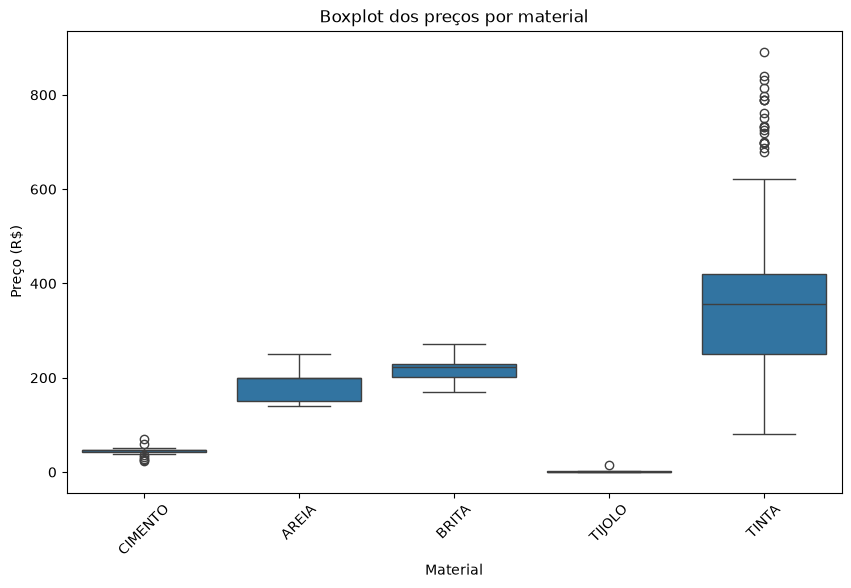

In [51]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_analise,
    x="material",
    y="preco"
)

plt.title(
    "Boxplot dos preços por material"
)

plt.xlabel("Material")
plt.ylabel("Preço (R$)")

plt.xticks(rotation=45)

plt.show()

In [52]:
lista_outliers = []

for material in materiais:

    grupo = df_analise[
        df_analise["material"] == material
    ]

    out = identificar_outliers(grupo)

    lista_outliers.append(out)

outliers = pd.concat(
    lista_outliers,
    ignore_index=True
)

display(
    outliers[
        [
            "material",
            "descricao",
            "unidade",
            "preco",
            "estabelecimento"
        ]
    ]
)

,material,descricao,unidade,preco,estabelecimento
0,CIMENTO,CIMENTO CP IV 32 RS 50 KG,SC,23.00,M R CONSTRUCOES
1,CIMENTO,CIMENTO 50KG ZEBU,UN,24.90,G SILVA MATERIAL DE CONSTRUÇÃO E FERRAGEM
2,CIMENTO,CIMENTO ZEBU USO GERAL CPII F32 50KG D...,UN,26.90,LEROY MERLIN COMPANHIA BRASILEIRA DE BRICOLAGEM
3,CIMENTO,CIMENTO NACIONAL CP-II-F-32 50 KG,SACO,31.40,GLOBAL CIMENTOS ALAGOAS LTDA
4,CIMENTO,CIMENTO INTERCEMENT 50KG,UN,35.39,JH COMERCIAL
5,CIMENTO,CIMENTO ZUMBI 50 KG,UNID,60.00,DEPOSITO ALVORADA
6,CIMENTO,CIMENTO POTY 50KG,UNID,70.00,DEPOSITO ALVORADA
7,TIJOLO,"TIJOLOS 8 FUROS 0,09 X 0,19 X",UN,15.00,HORIZONTE MATERIAIS DE CONSTRUCAO
8,TINTA,TINTA ACR PREMIUM DECORA SEDA BRANCO ACETINADO...,LA,678.84,Casas Jardim
9,TINTA,TINTA ACR PREMIUM TOQUE FOSCO COMPLETO CROMIO ...,LA,687.13,Casas Jardim


In [53]:
outliers_por_material = (
    outliers["material"]
    .value_counts()
    .rename_axis("material")
    .reset_index(name="quantidade_outliers")
)

display(outliers_por_material)

,material,quantidade_outliers
0,TINTA,21
1,CIMENTO,7
2,TIJOLO,1


## Histograma

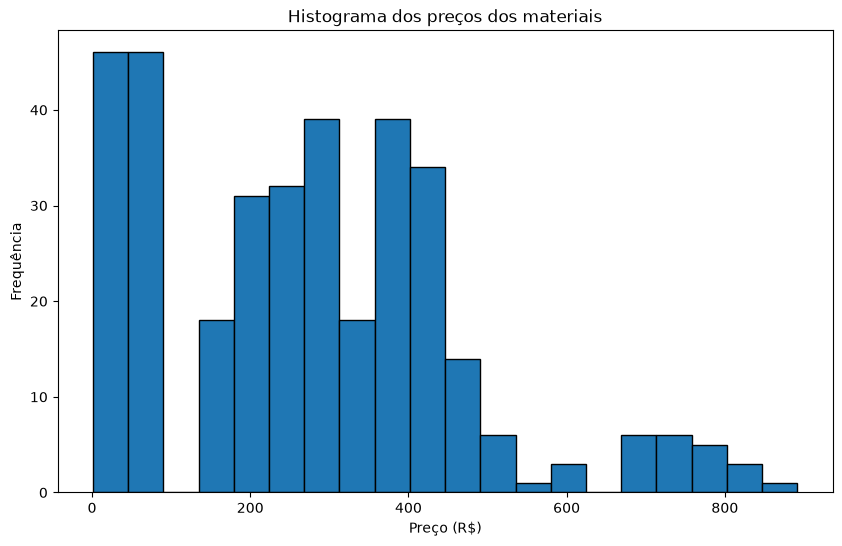

In [54]:
plt.figure(figsize=(10, 6))

plt.hist(
    df_analise["preco"],
    bins=20,
    edgecolor="black"
)

plt.title(
    "Histograma dos preços dos materiais"
)

plt.xlabel("Preço (R$)")
plt.ylabel("Frequência")

plt.show()

## Distribuição

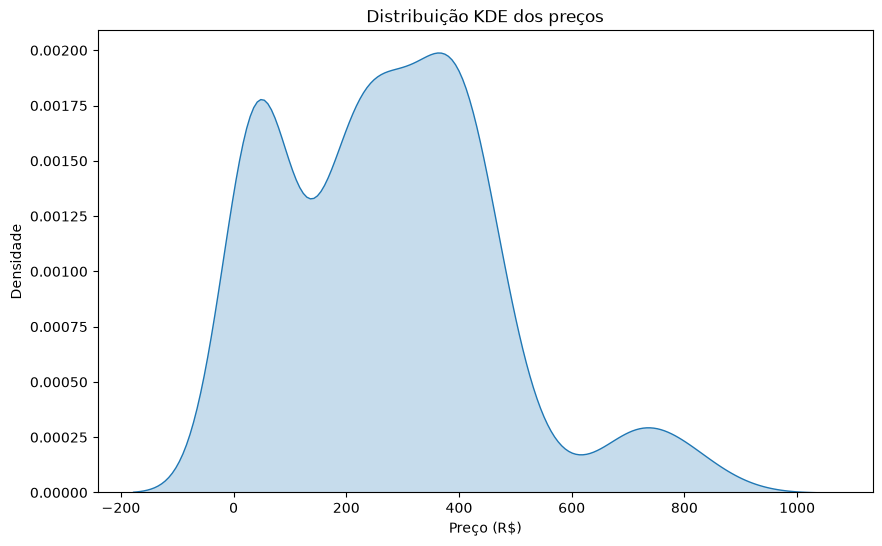

In [55]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df_analise,
    x="preco",
    fill=True
)

plt.title(
    "Distribuição KDE dos preços"
)

plt.xlabel("Preço (R$)")
plt.ylabel("Densidade")

plt.show()

Média: R$ 274.71
Mediana: R$ 270.92


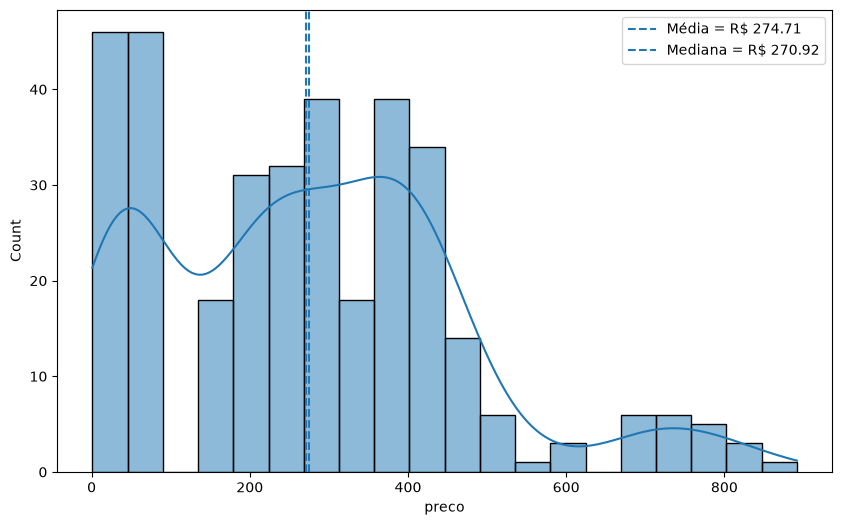

In [56]:
media = df_analise["preco"].mean()
mediana = df_analise["preco"].median()

print(
    f"Média: R$ {media:.2f}"
)

print(
    f"Mediana: R$ {mediana:.2f}"
)

plt.figure(figsize=(10, 6))

sns.histplot(
    df_analise["preco"],
    bins=20,
    kde=True
)

plt.axvline(
    media,
    linestyle="--",
    label=f"Média = R$ {media:.2f}"
)

plt.axvline(
    mediana,
    linestyle="--",
    label=f"Mediana = R$ {mediana:.2f}"
)

plt.legend()

plt.show()

## Distribuição dos preços por material

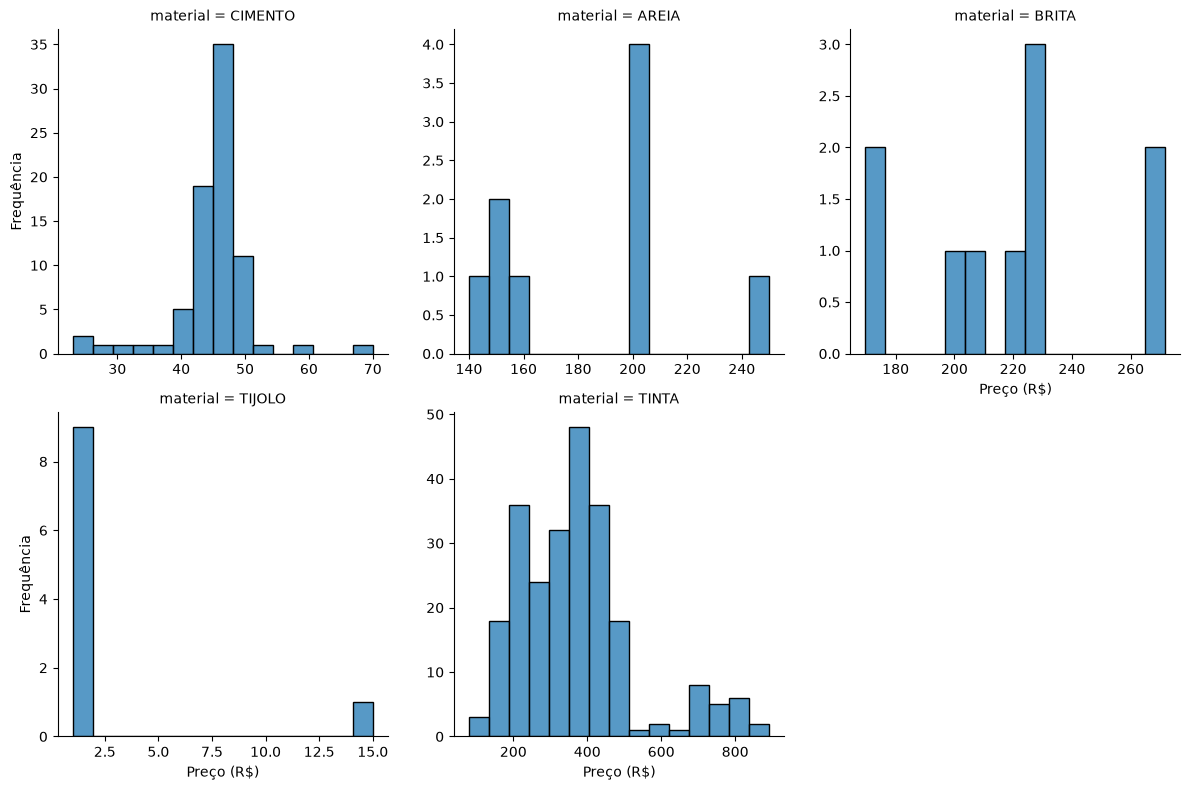

In [57]:
g = sns.FacetGrid(
    df_analise,
    col="material",
    col_wrap=3,
    height=4,
    sharex=False,
    sharey=False
)

g.map_dataframe(
    sns.histplot,
    x="preco",
    bins=15
)

g.set_axis_labels(
    "Preço (R$)",
    "Frequência"
)

plt.show()

In [58]:
print("Ordenado pelo desvio-padrão:")

display(
    resumo.sort_values(
        "desvio_padrao",
        ascending=False
    )
)

print("\nOrdenado pela amplitude:")

display(
    resumo.sort_values(
        "amplitude",
        ascending=False
    )
)

print("\nOrdenado pelo coeficiente de variação:")

display(
    resumo.sort_values(
        "cv_percentual",
        ascending=False
    )
)

Ordenado pelo desvio-padrão:


,quantidade,media,mediana,minimo,maximo,desvio_padrao,amplitude,cv_percentual
material,,,,,,,,
TINTA,240,367.412250,356.40,80.00,891.71,156.300901,811.71,42.541015
AREIA,9,183.333333,200.00,140.00,250.00,35.707142,110.00,19.476623
BRITA,10,219.350000,222.50,169.66,271.84,34.978209,102.18,15.946300
CIMENTO,79,44.936354,46.00,23.00,70.00,6.173541,47.00,13.738410
TIJOLO,10,2.559800,1.15,1.00,15.00,4.373784,14.00,170.864269



Ordenado pela amplitude:


,quantidade,media,mediana,minimo,maximo,desvio_padrao,amplitude,cv_percentual
material,,,,,,,,
TINTA,240,367.412250,356.40,80.00,891.71,156.300901,811.71,42.541015
AREIA,9,183.333333,200.00,140.00,250.00,35.707142,110.00,19.476623
BRITA,10,219.350000,222.50,169.66,271.84,34.978209,102.18,15.946300
CIMENTO,79,44.936354,46.00,23.00,70.00,6.173541,47.00,13.738410
TIJOLO,10,2.559800,1.15,1.00,15.00,4.373784,14.00,170.864269



Ordenado pelo coeficiente de variação:


,quantidade,media,mediana,minimo,maximo,desvio_padrao,amplitude,cv_percentual
material,,,,,,,,
TIJOLO,10,2.559800,1.15,1.00,15.00,4.373784,14.00,170.864269
TINTA,240,367.412250,356.40,80.00,891.71,156.300901,811.71,42.541015
AREIA,9,183.333333,200.00,140.00,250.00,35.707142,110.00,19.476623
BRITA,10,219.350000,222.50,169.66,271.84,34.978209,102.18,15.946300
CIMENTO,79,44.936354,46.00,23.00,70.00,6.173541,47.00,13.738410
